In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('healthcare_dataset.csv')

In [3]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328.0,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265.0,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205.0,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450.0,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458.0,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
df.describe()

,Age,Billing Amount,Room Number
count,34636.000000,34636.000000,34635.000000
mean,51.587077,25588.435564,300.579039
std,19.574430,14211.630822,115.235115
min,18.000000,-1316.618581,101.000000
25%,35.000000,13279.808156,201.000000
50%,52.000000,25591.515509,301.000000
75%,69.000000,37874.997382,400.000000
max,85.000000,52373.032374,500.000000


In [5]:
df.shape

(34636, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34636 entries, 0 to 34635
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                34636 non-null  object 
 1   Age                 34636 non-null  int64  
 2   Gender              34636 non-null  object 
 3   Blood Type          34636 non-null  object 
 4   Medical Condition   34636 non-null  object 
 5   Date of Admission   34636 non-null  object 
 6   Doctor              34636 non-null  object 
 7   Hospital            34636 non-null  object 
 8   Insurance Provider  34636 non-null  object 
 9   Billing Amount      34636 non-null  float64
 10  Room Number         34635 non-null  float64
 11  Admission Type      34635 non-null  object 
 12  Discharge Date      34635 non-null  object 
 13  Medication          34635 non-null  object 
 14  Test Results        34635 non-null  object 
dtypes: float64(2), int64(1), object(12)
memory usage: 4.0

In [7]:
df = df.drop_duplicates()

In [71]:
df = df.drop(columns = ["room_number", "medication"])

In [72]:
df.columns = df.columns.str.lower()

In [73]:
df.columns = df.columns.str.replace(" ", "_")

In [78]:
df.columns

Index(['name', 'age', 'gender', 'blood_type', 'medical_condition',
       'date_of_admission', 'doctor', 'hospital', 'insurance_provider',
       'billing_amount', 'admission_type', 'discharge_date', 'test_results',
       'year_of_admission', 'no_of_days_admitted'],
      dtype='object')

# **Handling the Missing value**

In [111]:
drop_row = df[df["name"] == "Lisa Webster"]
df = df.drop(drop_row.index)


In [118]:
df = df.drop(columns=["test_results"])

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34635 entries, 0 to 34634
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   name                 34635 non-null  object        
 1   age                  34635 non-null  int64         
 2   gender               34635 non-null  object        
 3   blood_type           34635 non-null  object        
 4   medical_condition    34635 non-null  object        
 5   date_of_admission    34635 non-null  datetime64[ns]
 6   doctor               34635 non-null  object        
 7   hospital             34635 non-null  object        
 8   insurance_provider   34635 non-null  object        
 9   billing_amount       34635 non-null  float64       
 10  admission_type       34635 non-null  object        
 11  discharge_date       34635 non-null  datetime64[ns]
 12  year_of_admission    34635 non-null  int32         
 13  no_of_days_admitted  34635 non-

In [75]:
cdf["hospital"].unique()

array(['Sons and Miller', 'Kim Inc', 'Cook PLC', ..., 'Daniels Ltd',
       'Anderson-Jarvis', 'Baker-Arellano'], dtype=object)

In [76]:
df["name"] = df["name"].str.title()

In [77]:
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,admission_type,discharge_date,test_results,year_of_admission,no_of_days_admitted
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew_Smith,Sons and Miller,Blue Cross,18856.28,Urgent,2024-02-02,Normal,2024,2.0
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha_Davies,Kim Inc,Medicare,33643.33,Emergency,2019-08-26,Inconclusive,2019,6.0
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany_Mitchell,Cook PLC,Aetna,27955.10,Emergency,2022-10-07,Normal,2022,15.0
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin_Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,Elective,2020-12-18,Abnormal,2020,30.0
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen_Hanna,White-White,Aetna,14238.32,Urgent,2022-10-09,Abnormal,2022,20.0


# Top 5 Hospitals having more no. of Patients Admitted

Text(0.5, 1.0, 'Top 5 Hospitals having more no. of Patients Admitted ')

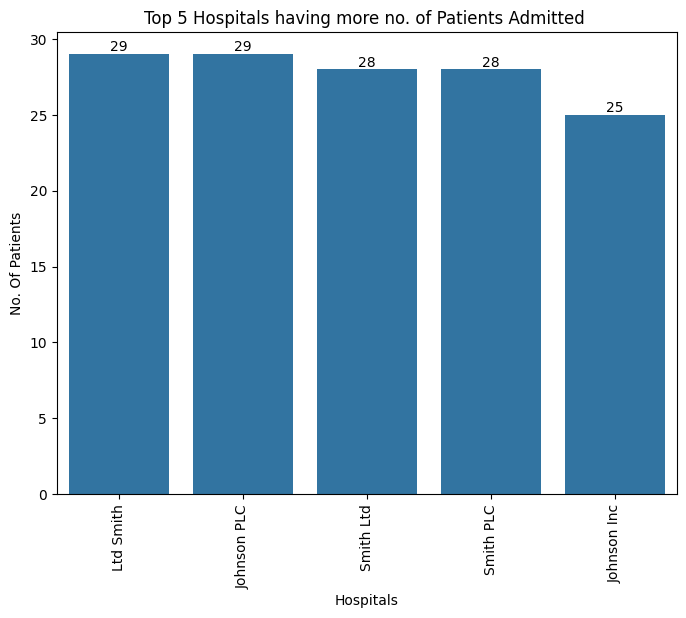

In [14]:
top_5_hospitals = df.groupby('hospital')['name'].count().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,6))
ax = sns.barplot(x=top_5_hospitals.index, y=top_5_hospitals.values)
ax.bar_label(ax.containers[0])
plt.xlabel("Hospitals")
plt.ylabel("No. Of Patients")
plt.xticks(rotation=90)
plt.title("Top 5 Hospitals having more no. of Patients Admitted ")

# Top5 hospitals making More revenue

Text(0.5, 1.0, 'Top5 hospitals making More revenue')

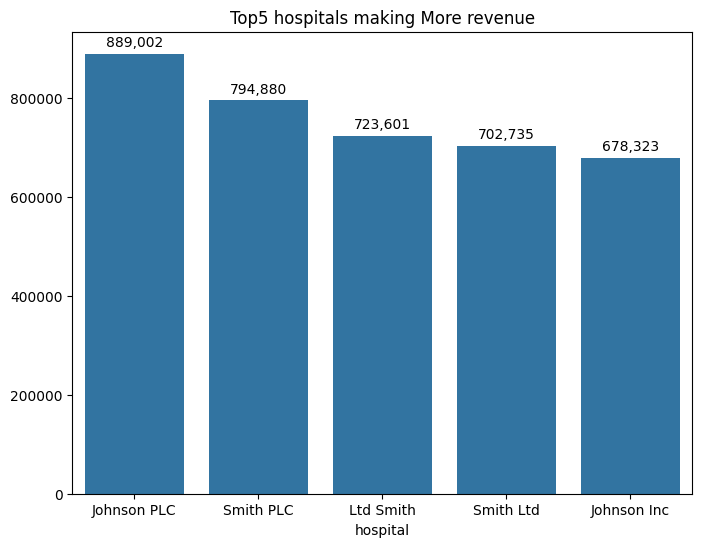

In [15]:
plt.figure(figsize=(8,6))
total_revenue_per_hospital = df.groupby('hospital')["billing_amount"].sum().sort_values(ascending=False).head()
total_revenue_per_hospital = total_revenue_per_hospital.astype(int)
ax = sns.barplot(x=total_revenue_per_hospital.index, y=total_revenue_per_hospital.values)
labels = [f"{int(x):,}" for x in total_revenue_per_hospital.values]
ax.bar_label(ax.containers[0], labels=labels, padding=3)
plt.title("Top5 hospitals making More revenue")

# **Top 5 hospitals charges more per patient on average**

Text(0.5, 1.0, 'Top 5 hospitals charges more per patient on average')

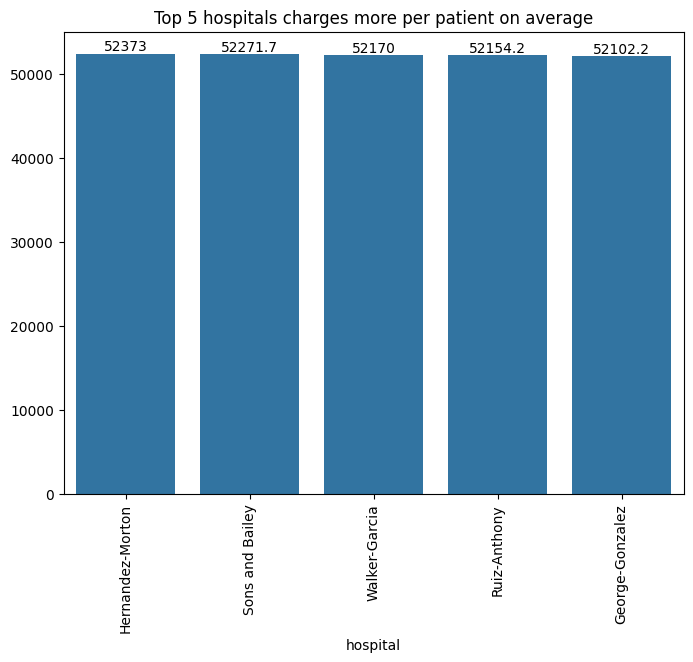

In [16]:
expensive_hospitals = df.groupby('hospital')["billing_amount"].mean().sort_values(ascending=False).head()
plt.figure(figsize=(8,6))
ax = sns.barplot(x=expensive_hospitals.index, y=expensive_hospitals.values)
plt.xticks(rotation=90)
plt.bar_label(ax.containers[0])
plt.title("Top 5 hospitals charges more per patient on average")

# No. of Patients are diagonsed with each medical condition

Text(0, 0.5, 'No of Patients')

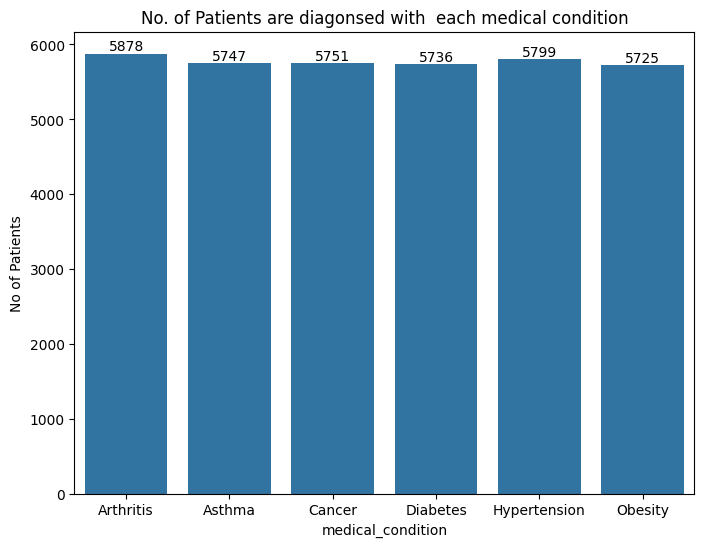

In [17]:
medical_condition = df.groupby('medical_condition')["name"].count()
plt.figure(figsize=(8,6))
ax = sns.barplot(x=medical_condition.index, y=medical_condition.values)
plt.bar_label(ax.containers[0])
plt.title("No. of Patients are diagonsed with  each medical condition")
plt.ylabel("No of Patients")

# **Admission Type analysis**

([<matplotlib.patches.Wedge at 0x7f2b63206d80>,
 [Text(-1.0478816402250124, 0.5847598379500233, 'Elective'),
  Text(0.009778002476597698, -1.0999565403540121, 'Emergency'),
  Text(0.9557550044645222, 0.5445478596423102, 'Urgent')],
 [Text(-0.6112642901312573, 0.3411099054708469, '33.8%'),
  Text(0.005333455896326016, -0.5999762947385521, '32.7%'),
  Text(0.5213209115261029, 0.2970261052594419, '33.5%')])

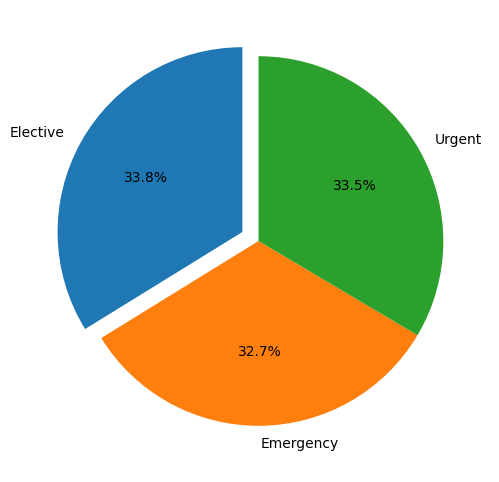

In [18]:
admission_type = df.groupby('admission_type')["name"].count()
plt.figure(figsize=(8,6))
plt.pie(admission_type, labels=admission_type.index, autopct='%1.1f%%', startangle=90, explode=(0.1,0,0))
# df['admission_type'].unique()

# **No. of Patients Associated with each Insurance Providers**

Text(0.5, 1.0, 'No. of Patients Associated with each Insurance Providers')

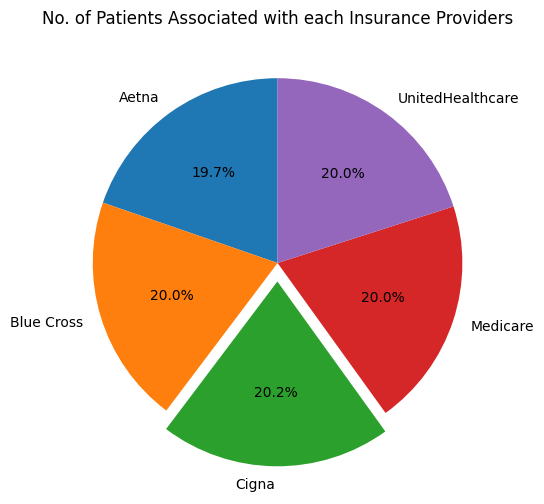

In [19]:
insurance_provider = df.groupby("insurance_provider")['name'].count()
plt.figure(figsize=(8,6))
plt.pie(insurance_provider, labels=insurance_provider.index, autopct='%1.1f%%', startangle=90, explode=(0,0,0.1,0,0))
plt.title("No. of Patients Associated with each Insurance Providers")

# **New Feature is created Year_of_Adminssion**

In [20]:
df["date_of_admission"] = pd.to_datetime(df["date_of_admission"], format="%Y-%m-%d")
df["year_of_admission"] = df["date_of_admission"].dt.year

In [21]:
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,year_of_admission
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328.0,Urgent,2024-02-02,Paracetamol,Normal,2024
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265.0,Emergency,2019-08-26,Ibuprofen,Inconclusive,2019
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205.0,Emergency,2022-10-07,Aspirin,Normal,2022
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450.0,Elective,2020-12-18,Ibuprofen,Abnormal,2020
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458.0,Urgent,2022-10-09,Penicillin,Abnormal,2022


In [22]:
df["billing_amount"] = round(df["billing_amount"], 2)

In [23]:
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,year_of_admission
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328.0,Urgent,2024-02-02,Paracetamol,Normal,2024
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265.0,Emergency,2019-08-26,Ibuprofen,Inconclusive,2019
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205.0,Emergency,2022-10-07,Aspirin,Normal,2022
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450.0,Elective,2020-12-18,Ibuprofen,Abnormal,2020
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458.0,Urgent,2022-10-09,Penicillin,Abnormal,2022


In [24]:
df["year_of_admission"].sort_values(ascending=False).unique()

array([2024, 2023, 2022, 2021, 2020, 2019], dtype=int32)

# **No. of patients admitted Every year**

Text(0, 0.5, 'No. of Patients')

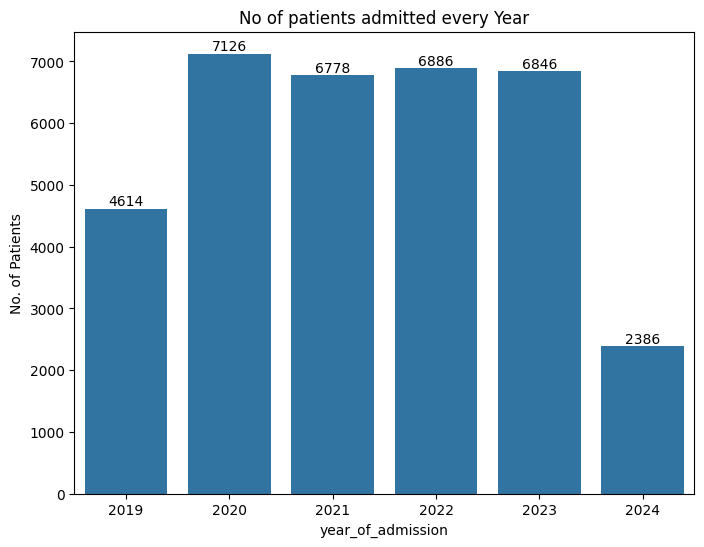

In [25]:
patients_count_every_year = df.groupby("year_of_admission")["name"].count()
plt.figure(figsize=(8,6))
ax = sns.barplot(x=patients_count_every_year.index, y=patients_count_every_year.values)
ax.bar_label(ax.containers[0])
plt.title("No of patients admitted every Year")
plt.ylabel("No. of Patients")
# patients_count_every_year.index


# **Medical Condition Vs Gender**

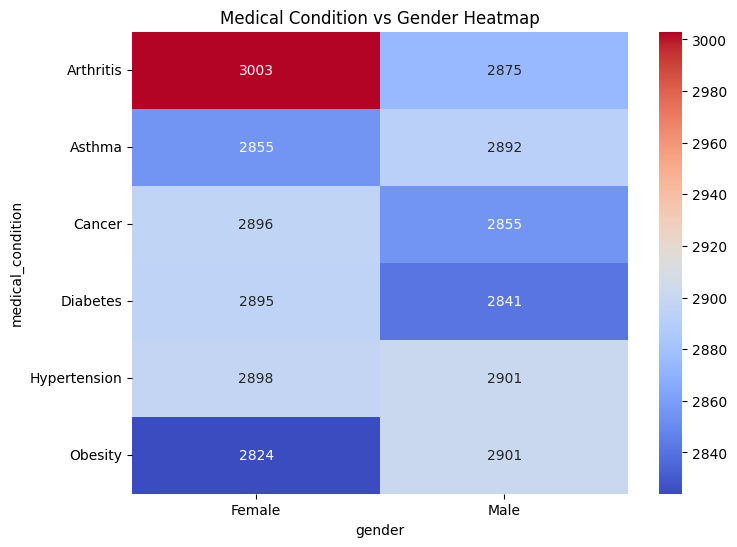

In [26]:
pivot = df.groupby(["medical_condition", "gender"]).size().unstack()
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="coolwarm")
plt.title("Medical Condition vs Gender Heatmap")
plt.show()

# **Age Distribution of Patients**

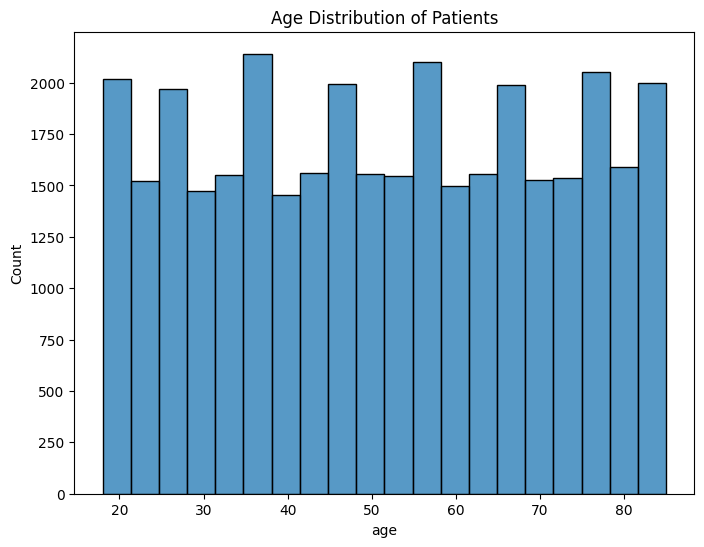

In [27]:
plt.figure(figsize=(8,6))
sns.histplot(df["age"], bins=20)
plt.title("Age Distribution of Patients")
plt.show()

# **Billing Distribution by Medical Condition**

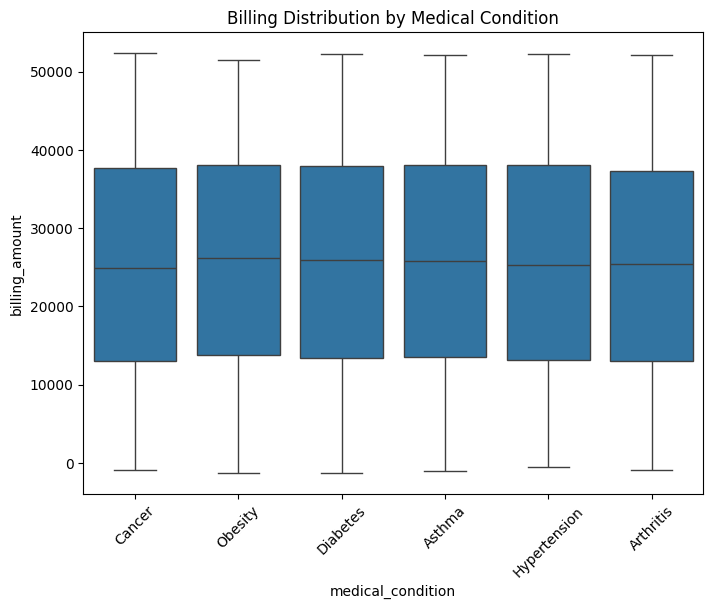

In [28]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="medical_condition", y="billing_amount")
plt.xticks(rotation=45)
plt.title("Billing Distribution by Medical Condition")
plt.show()

([<matplotlib.patches.Wedge at 0x7f2b6286c6e0>,
 [Text(-0.4195226201846848, 1.0168582846952554, 'A+'),
  Text(-1.1064561783907727, 0.4644940530307, 'A-'),
  Text(-1.0148298316616053, -0.42440595279717486, 'AB+'),
  Text(-0.4062984160436944, -1.0222140661918055, 'AB-'),
  Text(0.4373494854928658, -1.009319289194022, 'B+'),
  Text(1.0233889163939986, -0.4033300457465541, 'B-'),
  Text(1.0093986567625728, 0.4371662746895212, 'O+'),
  Text(0.4135203351102449, 1.0193139518569885, 'O-')],
 [Text(-0.22883052010073712, 0.5546499734701392, '12.5%'),
  Text(-0.6454327707279506, 0.2709548642679083, '12.4%'),
  Text(-0.5535435445426938, -0.23149415607118623, '12.8%'),
  Text(-0.22161731784201508, -0.5575713088318939, '12.5%'),
  Text(0.23855426481429037, -0.5505377941058301, '12.5%'),
  Text(0.5582121362149083, -0.21999820677084767, '12.5%'),
  Text(0.5505810855068578, 0.2384543316488297, '12.5%'),
  Text(0.2255565464237699, 0.55598942828563, '12.3%')])

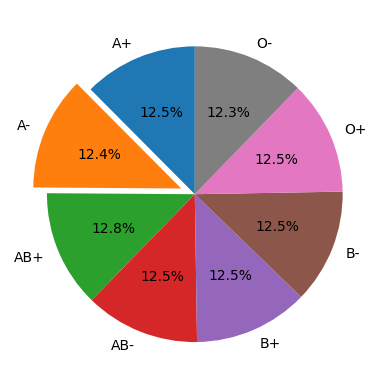

In [29]:
blood_type = df.groupby("blood_type")["name"].count()
plt.pie(blood_type, labels=blood_type.index, autopct="%1.1f%%", startangle=90, explode=(0,0.1,0,0,0,0,0,0))

In [30]:
df["doctor"] = df["doctor"].str.replace(" ", "_")

# **Top 5 Doctors Treated More patients**

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Robert_Smith'),
  Text(1, 0, 'John_Smith'),
  Text(2, 0, 'James_Smith'),
  Text(3, 0, 'Michael_Smith'),
  Text(4, 0, 'Christopher_Smith')])

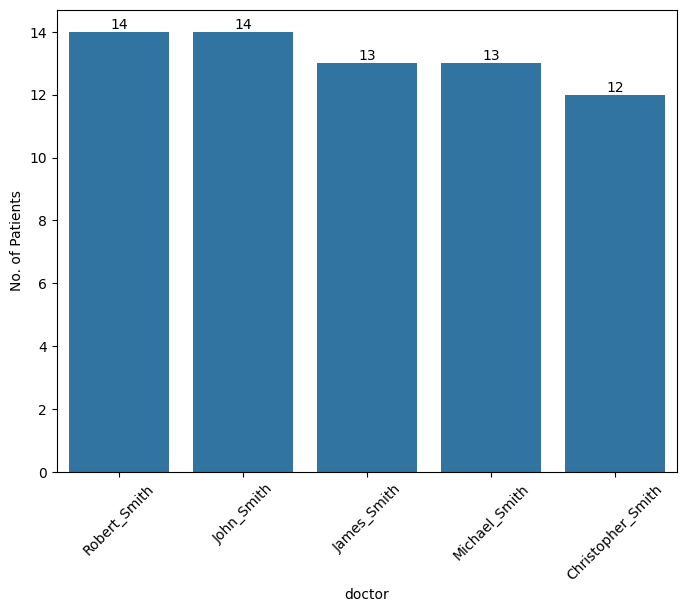

In [31]:
top5_doctors = df["doctor"].value_counts().head()
plt.figure(figsize=(8,6))
ax = sns.barplot(x=top5_doctors.index, y=top5_doctors.values)
ax.bar_label(ax.containers[0])
plt.ylabel("No. of Patients")
plt.xticks(rotation=45)


# **Blood type Vs Medical condition**

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0.5, 0, 'Arthritis'),
  Text(1.5, 0, 'Asthma'),
  Text(2.5, 0, 'Cancer'),
  Text(3.5, 0, 'Diabetes'),
  Text(4.5, 0, 'Hypertension'),
  Text(5.5, 0, 'Obesity')])

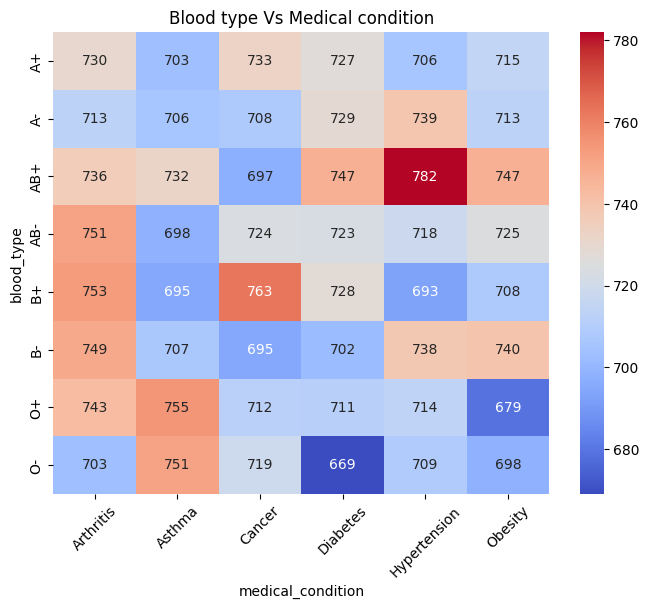

In [32]:
blood_type_vs_medical_cond = df.groupby(["blood_type","medical_condition"]).size().unstack()
plt.figure(figsize=(8,6))
sns.heatmap(blood_type_vs_medical_cond, annot=True, fmt="d", cmap="coolwarm")
plt.title("Blood type Vs Medical condition")
plt.xticks(rotation=45)

In [33]:
df["discharge_date"] = pd.to_datetime(df["discharge_date"], format="%Y-%m-%d")
df["no_of_days_admitted"] = (df["discharge_date"] - df["date_of_admission"]).dt.days

In [34]:
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,year_of_admission,no_of_days_admitted
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew_Smith,Sons and Miller,Blue Cross,18856.28,328.0,Urgent,2024-02-02,Paracetamol,Normal,2024,2.0
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha_Davies,Kim Inc,Medicare,33643.33,265.0,Emergency,2019-08-26,Ibuprofen,Inconclusive,2019,6.0
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany_Mitchell,Cook PLC,Aetna,27955.10,205.0,Emergency,2022-10-07,Aspirin,Normal,2022,15.0
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin_Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450.0,Elective,2020-12-18,Ibuprofen,Abnormal,2020,30.0
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen_Hanna,White-White,Aetna,14238.32,458.0,Urgent,2022-10-09,Penicillin,Abnormal,2022,20.0


In [35]:
round(df.groupby('medical_condition')['no_of_days_admitted'].mean().sort_values(ascending=True),2)

,no_of_days_admitted
medical_condition,
Diabetes,15.41
Hypertension,15.41
Obesity,15.41
Arthritis,15.53
Cancer,15.53
Asthma,15.57


# **Top 5 hospitals with more no of Doctors**

Text(0.5, 1.0, 'Top 5 hospitals with more no of Doctors')

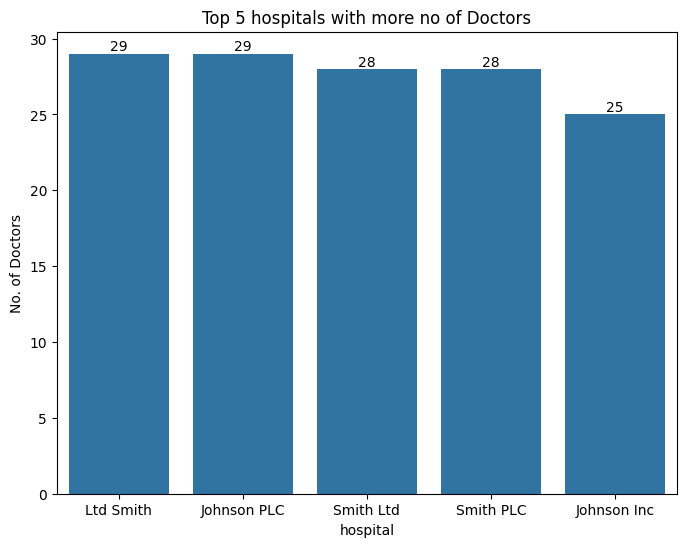

In [36]:
more_doctors = df.groupby('hospital')["doctor"].nunique().sort_values(ascending=False).head()
plt.figure(figsize=(8,6))
ax = sns.barplot(x=more_doctors.index, y=more_doctors.values)
ax.bar_label(ax.containers[0])
plt.ylabel("No. of Doctors")
plt.title("Top 5 hospitals with more no of Doctors")

# **Doctors which handled more Cancer patients**

Text(0, 0.5, 'No. of Patients')

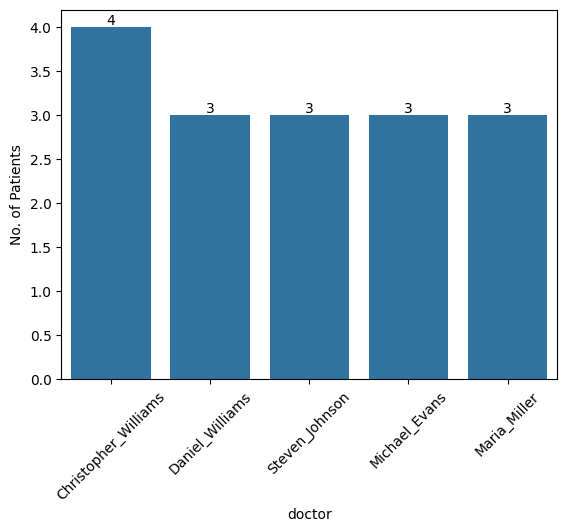

In [48]:
cancer_df = df[(df["medical_condition"] == "Cancer")]

total_doctors = cancer_df["doctor"].value_counts().head()
ax = sns.barplot(x=total_doctors.index, y=total_doctors.values)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45)
plt.ylabel("No. of Patients")

# **Top Revenue Generating Hospitals each Year**

Text(0.5, 1.0, 'Top Revenue Generating Hospitals each Year')

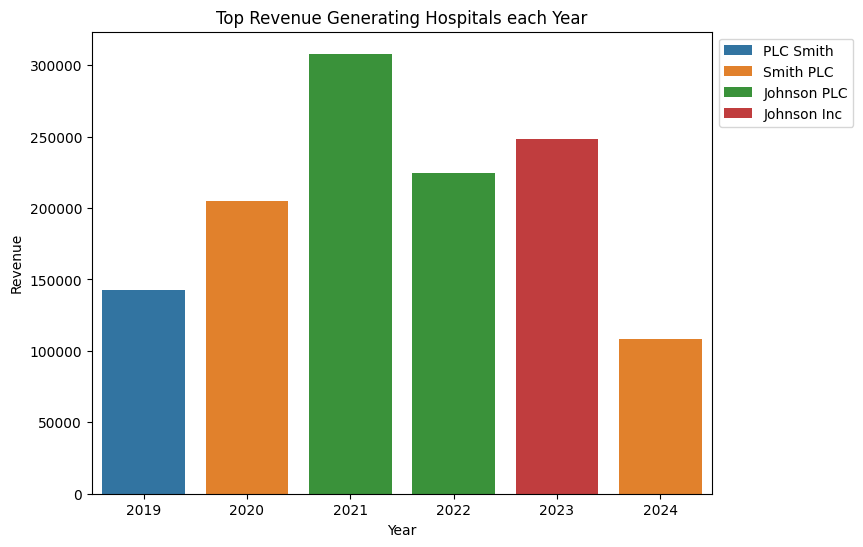

In [69]:
top_hospital_each_year = df.groupby(["year_of_admission", "hospital"])["billing_amount"].sum().reset_index()
top_hospital_each_year = top_hospital_each_year.loc[top_hospital_each_year.groupby("year_of_admission")["billing_amount"].idxmax()]
plt.figure(figsize=(8,6))
ax = sns.barplot(data=top_hospital_each_year, x="year_of_admission", y="billing_amount", hue="hospital")
plt.legend(bbox_to_anchor=(1,1), loc="upper left")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Top Revenue Generating Hospitals each Year")
